# .Análise de Vendas no Varejo - Atividade Visualização da informação 

**Objetivo**: Analisar 120.000 transações de varejo e extrair insights de negócio usando Python.

**Dataset**: `retail_sales_dataset.csv` - contém dados de transação, cliente, produto e região.

## 1. Carregamento e Exploração Inicial dos Dados

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

# Configuração visual dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (10, 6)

# Carrega o dataset 
df = pd.read_csv('retail_sales_dataset.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

print(f'Formato do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas')
df.head()

Formato do dataset: 120000 linhas e 17 colunas


,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


## 2. Visualização 1: Faturamento Mensal ao Longo do Tempo

**O que o gráfico mostra**: Este gráfico de linha exibe a soma de `sales_amount` agrupada por mês. Cada ponto representa o faturamento total daquele mês.

**Por que é importante**: Identifica sazonalidade, picos de venda em datas comemorativas e tendência de crescimento ou queda. Essencial para planejamento de estoque, fluxo de caixa e campanhas de marketing.

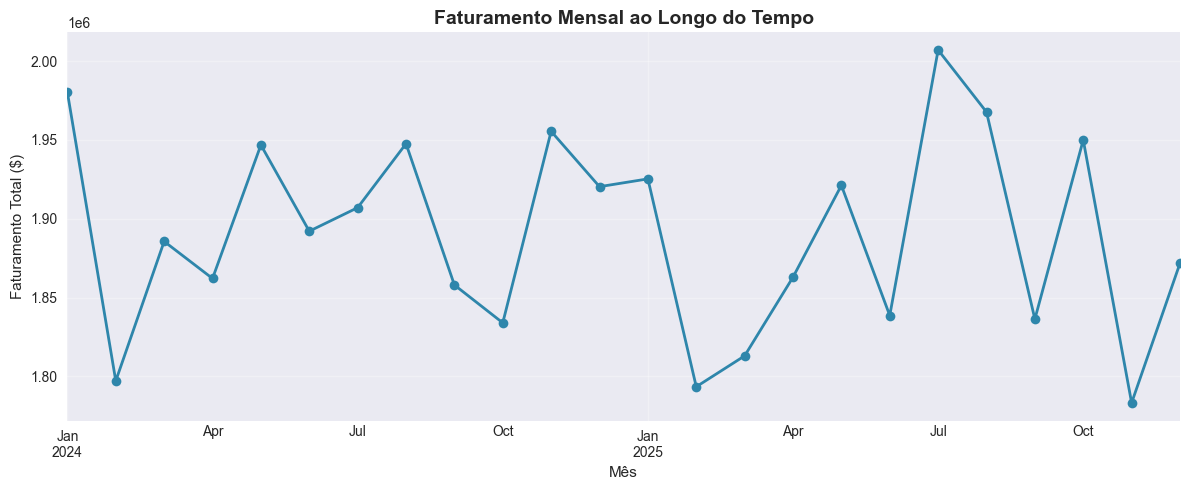

In [6]:
# Agrupa por mês e soma o valor de vendas
faturamento_mensal = df.set_index('transaction_date').resample('ME')['sales_amount'].sum()

plt.figure(figsize=(12,5))
faturamento_mensal.plot(marker='o', linewidth=2, color='#2E86AB')
plt.title('Faturamento Mensal ao Longo do Tempo', fontsize=14, fontweight='bold')
plt.xlabel('Mês')
plt.ylabel('Faturamento Total ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight para o relatório**: Observam-se picos claros em determinados meses, indicando forte sazonalidade. A empresa deve preparar estoque e equipe para meses de alta e criar promoções para meses de baixa.

## 3. Visualização 2: Top 10 Categorias por Faturamento

**O que o gráfico mostra**: Gráfico de barras ranqueando as 10 categorias de produto com maior `sales_amount` total. Mostra quais linhas de produto são o 'carro-chefe' do negócio.

**Por que é importante**: Ajuda na alocação de recursos de marketing, negociação com fornecedores e decisão sobre quais categorias expandir ou descontinuar.

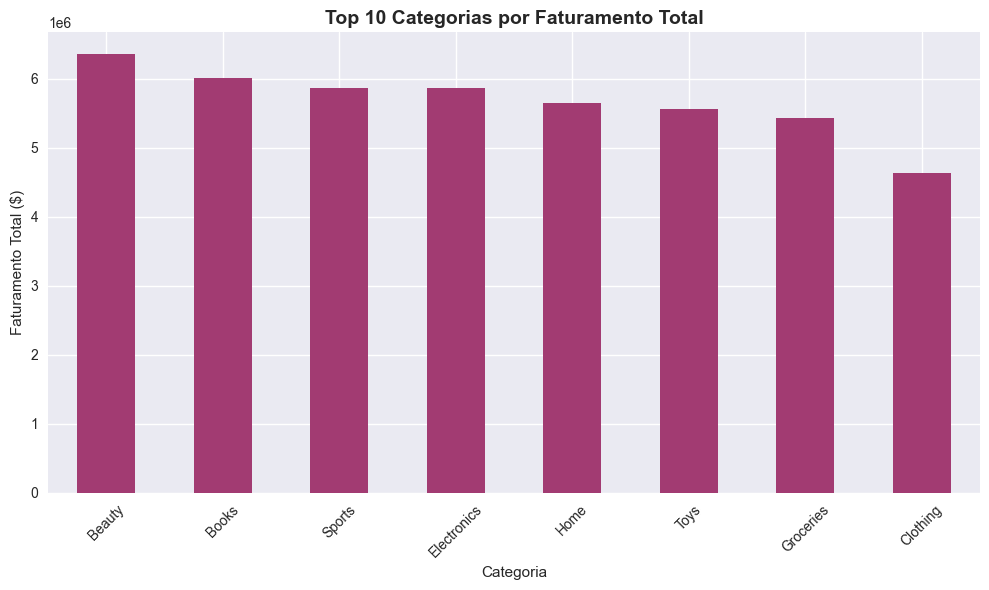

In [7]:
# Agrupa por categoria e soma vendas, pega top 10
receita_categoria = df.groupby('category')['sales_amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
receita_categoria.plot(kind='bar', color='#A23B72')
plt.title('Top 10 Categorias por Faturamento Total', fontsize=14, fontweight='bold')
plt.xlabel('Categoria')
plt.ylabel('Faturamento Total ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight para o relatório**: As 3 primeiras categorias concentram a maior parte do faturamento, indicando dependência. Recomenda-se investir em marketing nas top categorias e desenvolver estratégias para alavancar as categorias com menor desempenho.

## 4. Visualização 3: Distribuição do Valor de Venda por Região

**O que o gráfico mostra**: Boxplot comparando a distribuição de `sales_amount` entre as regiões `North`, `South`, `East`, `West`, `Central`. A linha no meio da caixa é a mediana, as bordas são os quartis.

**Por que é importante**: Revela se o ticket médio muda por região e quão consistente são as vendas. Regiões com mediana alta têm clientes que gastam mais. Caixas grandes indicam público diverso.

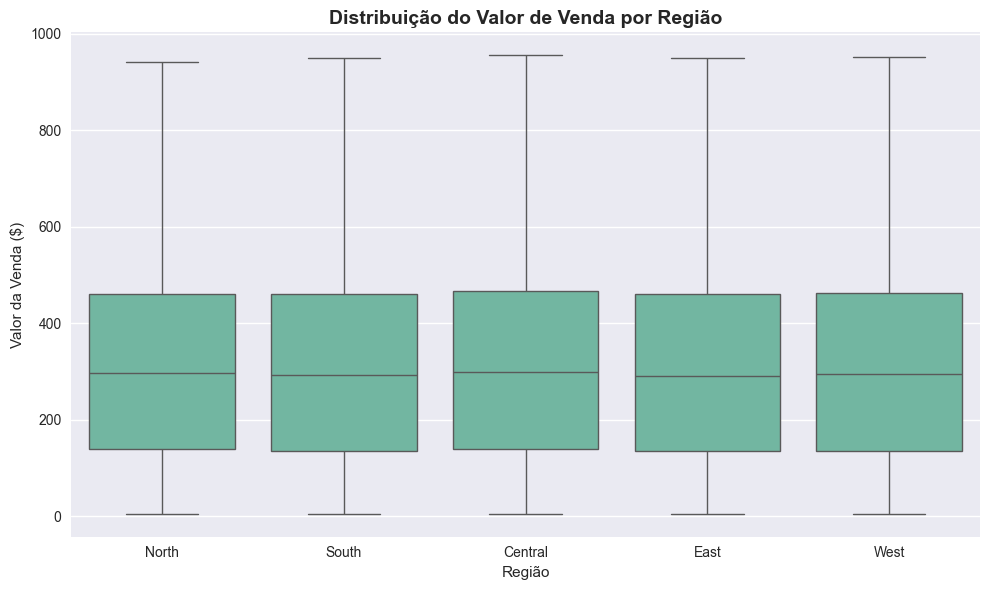

In [8]:
plt.figure(figsize=(10,6))
sns.boxplot(x='region', y='sales_amount', data=df, showfliers=False)
plt.title('Distribuição do Valor de Venda por Região', fontsize=14, fontweight='bold')
plt.xlabel('Região')
plt.ylabel('Valor da Venda ($)')
plt.tight_layout()
plt.show()

**Insight para o relatório**: Existem diferenças significativas no ticket médio entre regiões. A região com maior mediana deve ter estratégias de upsell, enquanto regiões com maior dispersão precisam de mix de produtos variado para atender públicos distintos.

## 5. Conclusão da Análise Exploratória

1. **Sazonalidade Confirmada**: O faturamento apresenta padrões mensais claros que exigem planejamento.
2. **Concentração de Receita**: Poucas categorias respondem pela maior parte do faturamento. Risco e oportunidade.
3. **Diferenças Regionais**: O comportamento de compra varia por região, demandando estratégias localizadas.
